<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ci%C3%AAncias_de_Dados_Aula7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biblioteca Pandas e dados de séries temporais em paineis

por **Cibele Russo**

**ICMC/USP - São Carlos SP**

A biblioteca Pandas pode ser usada para a análise e modelagem de dados de séries temporais, que são dados coletados ao longo do tempo.

In [1]:
import pandas as pd

url='https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/PETR4.csv'
df = pd.read_csv(url)

df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-03-18,11.790000,12.270000,10.870000,11.290000,11.289389,162515200
1,2020-03-19,11.070000,13.070000,10.850000,12.210000,12.209339,157065200
2,2020-03-20,13.110000,13.500000,11.830000,12.000000,11.999351,149029900
3,2020-03-23,12.110000,12.180000,11.280000,11.500000,11.499378,107092400
4,2020-03-24,12.570000,13.540000,12.280000,13.250000,13.249283,114259200
...,...,...,...,...,...,...,...
79,2020-07-13,22.610001,22.650000,22.160000,22.160000,22.160000,55425500
80,2020-07-14,22.129999,22.959999,21.860001,22.900000,22.900000,89380500
81,2020-07-15,23.200001,23.430000,22.850000,23.340000,23.340000,58390600
82,2020-07-16,23.160000,23.280001,22.520000,22.719999,22.719999,69698700


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/PETR4.csv"
df = pd.read_csv(url)

df


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-03-18,11.790000,12.270000,10.870000,11.290000,11.289389,162515200
1,2020-03-19,11.070000,13.070000,10.850000,12.210000,12.209339,157065200
2,2020-03-20,13.110000,13.500000,11.830000,12.000000,11.999351,149029900
3,2020-03-23,12.110000,12.180000,11.280000,11.500000,11.499378,107092400
4,2020-03-24,12.570000,13.540000,12.280000,13.250000,13.249283,114259200
...,...,...,...,...,...,...,...
79,2020-07-13,22.610001,22.650000,22.160000,22.160000,22.160000,55425500
80,2020-07-14,22.129999,22.959999,21.860001,22.900000,22.900000,89380500
81,2020-07-15,23.200001,23.430000,22.850000,23.340000,23.340000,58390600
82,2020-07-16,23.160000,23.280001,22.520000,22.719999,22.719999,69698700


In [3]:
df["Date"] = pd.to_datetime(df["Date"])



<Axes: >

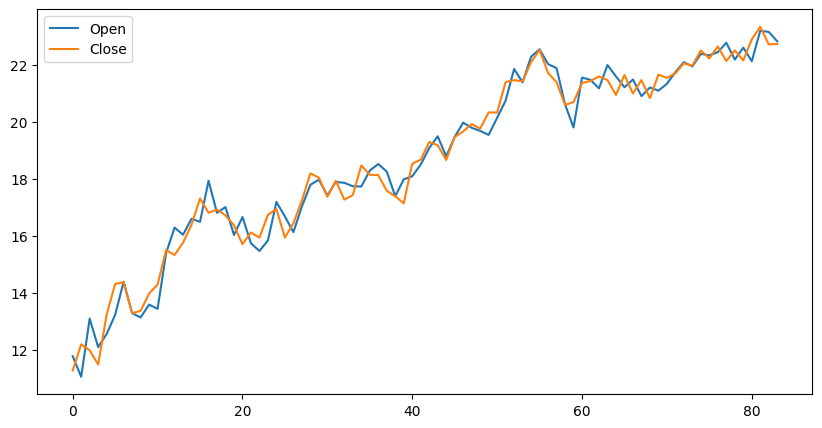

In [4]:
# Visualização de dados de séries temporais: gráfico de linha

df[['Open','Close']].plot(figsize=(10, 5))

## Agora vejamos dados de séries temporais em painel


RRRP3: A 3R Petroleum é uma companhia especializada na revitalização de campos maduros de petróleo e foi fundada em 2014. Os principais ativos da companhia são os complexos Potiguar, Recôncavo e Peróa, além do campo offshore de Papa Terra. Em agosto de 2024, a petrolífera concluiu a incorporação da Enauta, empresa de exploração de petróleo, que detém participação em blocos de extração de petróleo no campo de Manati, no litoral da Bahia, e no campo de Atlanta, no litoral do Rio de janeiro. Fonte: Infomoney https://www.infomoney.com.br/cotacoes/b3/acao/3rpetroleum-rrrp3/

PRIO3: A PetroRio S.A. é uma empresa especializada na gestão de reservatórios de petróleo e no redesenvolvimento de campos maduros. Atua com foco no investimento e na recuperação de ativos em produção. A empresa desenvolve o Campo de Polvo e Campo de Frade, ambos no litoral do Rio de Janeiro. Também está presente no Campo de Manati, no litoral da Bahia, e na Bacia da Foz do Amazonas. Fonte: https://www.infomoney.com.br/cotacoes/b3/acao/petrorio-prio3f/

In [5]:
#Fonte dos dados: Yahoo Finanças
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado-Dinamico/main/Data/RRRP3.csv', index_col=0, parse_dates=True)


df["Date"] = pd.to_datetime(df.index)
df["Ativo"] = "RRRP3"


In [6]:
df2 = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado-Dinamico/main/Data/PRIO3.csv', index_col=0, parse_dates=True)



df2["Date"] = pd.to_datetime(df2.index)
df2["Ativo"] = "PRIO3"

In [7]:
# Estrutura de painel

df_painel = df.set_index(["Ativo", "Date"]).copy()
df2_painel = df2.set_index(["Ativo", "Date"]).copy()


In [8]:
df_painel

Open       High        Low      Close  Adj Close  \
Ativo Date                                                                
RRRP3 2023-08-09  38.340000  38.980000  36.610001  36.880001  36.451939   
      2023-08-10  36.900002  37.200001  34.849998  35.049999  34.643177   
      2023-08-11  35.070000  35.310001  33.060001  33.400002  33.012329   
      2023-08-14  33.360001  33.410000  32.689999  33.040001  32.656509   
      2023-08-15  33.250000  33.380001  31.870001  32.480000  32.103008   
...                     ...        ...        ...        ...        ...   
      2024-08-02  26.639999  26.860001  25.770000  26.639999  26.639999   
      2024-08-05  25.990000  26.400000  25.670000  26.400000  26.400000   
      2024-08-06  26.230000  27.030001  26.160000  27.030001  27.030001   
      2024-08-07  27.309999  27.549999  26.860001  27.370001  27.370001   
      2024-08-08  27.330000  27.879999  27.139999  27.879999  27.879999   

                    Volume  
Ativo Date                  
RRRP3 2023-08-09  10512100  
      2023-08-10   9492700  
      2023-08-11   9860000  
      2023-08-14   5131500  
      2023-08-15   5277000  
...                    ...  
      2024-08-02   5940600  
      2024-08-05   5036500  
      2024-08-06   4691600  
      2024-08-07   4610500  
      2024-08-08   4461700  

[250 rows x 6 columns]

In [9]:
df2_painel

Open       High        Low      Close  Adj Close  \
Ativo Date                                                                
PRIO3 2023-08-09  48.360001  48.630001  47.680000  48.119999  48.042835   
      2023-08-10  48.200001  48.549999  46.959999  47.380001  47.304024   
      2023-08-11  47.779999  48.650002  47.669998  48.360001  48.282452   
      2023-08-14  48.340000  48.639999  47.750000  48.590000  48.512081   
      2023-08-15  47.900002  48.000000  45.910000  46.820000  46.744919   
...                     ...        ...        ...        ...        ...   
      2024-08-02  47.799999  48.009998  45.820000  46.009998  46.009998   
      2024-08-05  44.599998  45.560001  44.490002  44.669998  44.669998   
      2024-08-06  43.950001  44.389999  43.250000  43.250000  43.250000   
      2024-08-07  45.060001  45.389999  44.160000  45.070000  45.070000   
      2024-08-08  44.990002  46.459999  44.549999  46.360001  46.360001   

                    Volume  
Ativo Date                  
PRIO3 2023-08-09   5830000  
      2023-08-10   6333100  
      2023-08-11  14754200  
      2023-08-14   5984100  
      2023-08-15  14084400  
...                    ...  
      2024-08-02  11815700  
      2024-08-05  12727300  
      2024-08-06  14420700  
      2024-08-07  10045600  
      2024-08-08   7337800  

[250 rows x 6 columns]

In [10]:
# Juntar os painéis

df_total = pd.concat([df_painel, df2_painel])
df_total = df_total.sort_index()

df_total

Open       High        Low      Close  Adj Close  \
Ativo Date                                                                
PRIO3 2023-08-09  48.360001  48.630001  47.680000  48.119999  48.042835   
      2023-08-10  48.200001  48.549999  46.959999  47.380001  47.304024   
      2023-08-11  47.779999  48.650002  47.669998  48.360001  48.282452   
      2023-08-14  48.340000  48.639999  47.750000  48.590000  48.512081   
      2023-08-15  47.900002  48.000000  45.910000  46.820000  46.744919   
...                     ...        ...        ...        ...        ...   
RRRP3 2024-08-02  26.639999  26.860001  25.770000  26.639999  26.639999   
      2024-08-05  25.990000  26.400000  25.670000  26.400000  26.400000   
      2024-08-06  26.230000  27.030001  26.160000  27.030001  27.030001   
      2024-08-07  27.309999  27.549999  26.860001  27.370001  27.370001   
      2024-08-08  27.330000  27.879999  27.139999  27.879999  27.879999   

                    Volume  
Ativo Date                  
PRIO3 2023-08-09   5830000  
      2023-08-10   6333100  
      2023-08-11  14754200  
      2023-08-14   5984100  
      2023-08-15  14084400  
...                    ...  
RRRP3 2024-08-02   5940600  
      2024-08-05   5036500  
      2024-08-06   4691600  
      2024-08-07   4610500  
      2024-08-08   4461700  

[500 rows x 6 columns]

## Retorno em séries temporais

O **retorno** mede a variação percentual de uma variável (por exemplo, preço de um ativo) entre dois períodos consecutivos.

Matematicamente, o retorno no tempo \(t\) é dado por:

$$\text{Retorno}_t = \frac{x_t - x_{t-1}}{x_{t-1}}$$

onde:

- $x_t$ é o valor no tempo \(t\)
- $x_{t-1}$ é o valor no período anterior



### Interpretação

- Se o retorno for positivo → houve crescimento  
- Se for negativo → houve queda  
- Se for zero → não houve variação  



### Exemplo

Se o preço passa de 100 para 120:

$$\frac{120 - 100}{100} = 0,2 = 20\%$$

Ou seja, o ativo teve um retorno de **20%** no período.

Em Python, o retorno pode ser calculado com a função `.pct_change()` do pandas.

In [11]:
df_total["Retorno"] = df_total.groupby(level=0)["Close"].pct_change()


In [12]:
# Estatísticas por ativo

print("\n=== Estatísticas dos retornos por ativo ===")
df_total.groupby(level=0)["Retorno"].describe()



=== Estatísticas dos retornos por ativo ===


,count,mean,std,min,25%,50%,75%,max
Ativo,,,,,,,,
PRIO3,249.0,0.000044,0.019773,-0.046602,-0.013248,-0.001064,0.010712,0.087786
RRRP3,249.0,-0.000899,0.021220,-0.066667,-0.013518,-0.001511,0.011645,0.076190


In [13]:
# Volatilidade (desvio padrão)

volatilidade = df_total.groupby(level=0)["Retorno"].std()
print("\n=== Volatilidade por ativo ===")
print(volatilidade)



=== Volatilidade por ativo ===
Ativo
PRIO3    0.019773
RRRP3    0.021220
Name: Retorno, dtype: float64


In [14]:

# Média de preço

media_preco = df_total.groupby(level=0)["Close"].mean()
print("\n=== Preço médio por ativo ===")
print(media_preco)



=== Preço médio por ativo ===
Ativo
PRIO3    46.05780
RRRP3    29.86184
Name: Close, dtype: float64


In [15]:
# Pivot (comparação temporal)

pivot = df_total.reset_index().pivot(index="Date", columns="Ativo", values="Close")

print("\n=== Tabela pivot ===")
print(pivot.head())



=== Tabela pivot ===
Ativo           PRIO3      RRRP3
Date                            
2023-08-09  48.119999  36.880001
2023-08-10  47.380001  35.049999
2023-08-11  48.360001  33.400002
2023-08-14  48.590000  33.040001
2023-08-15  46.820000  32.480000


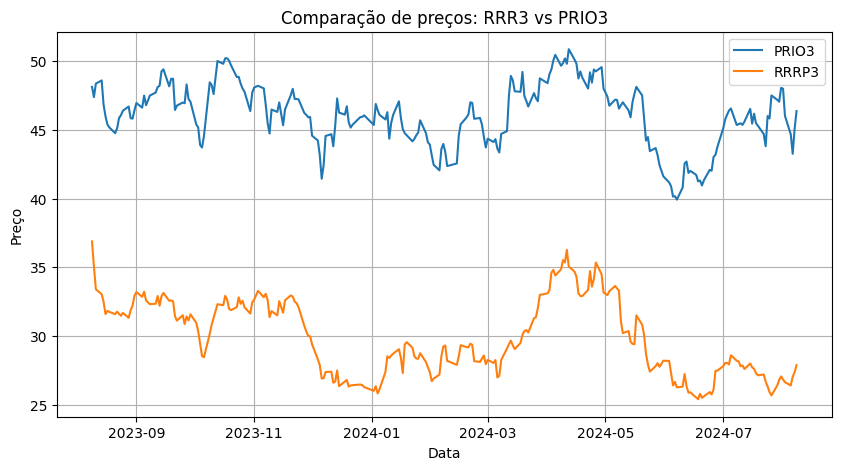

In [16]:
# Gráfico comparativo

plt.figure(figsize=(10, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)

plt.title("Comparação de preços: RRR3 vs PRIO3")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.grid(True)
plt.show()